## HUG-IML Benchmark Against Common Baselines
### A reproducible, evaluation-safe benchmark with bounded cross-validation and interpretable diagnostics.

The comparison uses local datasets and synthetic tabular problems so the workflow is reproducible without network access. Cross-validation is stratified, and each dataset is capped before CV when needed. HUG-IML preprocessing and pattern mining are performed inside the estimator fit on each training fold.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from hugiml import HUGIMLClassifierNative

RANDOM_STATE = 42
MAX_ROWS_FOR_CV = 500
N_SPLITS = 2

## 1. Dataset builders

The benchmark includes a medical dataset and two controlled synthetic risk datasets. Synthetic datasets are useful here because they allow nonlinear interactions and class imbalance to be created deliberately.

In [2]:
def make_healthcare_dataset():
    X, y = load_breast_cancer(as_frame=True, return_X_y=True)
    return X, pd.Series(y, name="benign")


def make_credit_risk_dataset(n=650):
    X, y = make_classification(
        n_samples=n,
        n_features=18,
        n_informative=8,
        n_redundant=4,
        weights=[0.68, 0.32],
        class_sep=0.9,
        flip_y=0.025,
        random_state=RANDOM_STATE,
    )
    cols = [f"risk_signal_{i:02d}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=cols)
    df["utilization_band"] = pd.qcut(df["risk_signal_00"], 4, labels=["low", "medium", "high", "very_high"]).astype(str)
    df["channel"] = np.where(df["risk_signal_01"] > 0, "digital", "branch")
    return df, pd.Series(y, name="default_flag")


def make_operational_risk_dataset(n=650):
    X, y = make_classification(
        n_samples=n,
        n_features=14,
        n_informative=6,
        n_redundant=2,
        weights=[0.82, 0.18],
        class_sep=0.75,
        flip_y=0.035,
        random_state=RANDOM_STATE + 7,
    )
    df = pd.DataFrame(X, columns=[f"control_metric_{i:02d}" for i in range(X.shape[1])])
    df["review_queue"] = pd.qcut(df["control_metric_02"], 3, labels=["standard", "watch", "urgent"]).astype(str)
    return df, pd.Series(y, name="case_escalated")


datasets = {
    "Healthcare diagnostic": make_healthcare_dataset(),
    "Credit risk": make_credit_risk_dataset(),
    "Operational risk": make_operational_risk_dataset(),
}

for name, (X, y) in datasets.items():
    print(f"{name:<24} rows={len(X):>5,}  features={X.shape[1]:>2}  positive_rate={y.mean():.3f}")

Healthcare diagnostic    rows=  569  features=30  positive_rate=0.627
Credit risk              rows=  650  features=20  positive_rate=0.318
Operational risk         rows=  650  features=15  positive_rate=0.195


## 2. Modeling utilities

HUG-IML receives explicit integer, float, and categorical column groups when a pandas DataFrame is used. Baseline models receive one-hot encoded features through pandas utilities inside the fold.

In [3]:
def cap_for_cv(X, y, max_rows=MAX_ROWS_FOR_CV):
    if len(X) <= max_rows:
        return X.reset_index(drop=True), pd.Series(y).reset_index(drop=True)
    _, X_s, _, y_s = next(StratifiedKFold(n_splits=int(np.ceil(len(X) / max_rows)), shuffle=True, random_state=RANDOM_STATE).split(X, y)), None, None, None


def stratified_cap(X, y, max_rows=MAX_ROWS_FOR_CV):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True) if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    if len(X) <= max_rows:
        return X, y
    from sklearn.model_selection import train_test_split
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=max_rows, stratify=y, random_state=RANDOM_STATE)
    return X_sample.reset_index(drop=True), y_sample.reset_index(drop=True)


def hug_for_frame(X_train):
    cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    int_cols = X_train.select_dtypes(include=["int", "int32", "int64"]).columns.tolist()
    flt_cols = [c for c in X_train.columns if c not in cat_cols + int_cols]
    return HUGIMLClassifierNative(
        allCols=[int_cols, flt_cols, cat_cols],
        origColumns=X_train.columns.tolist(),
        B=7,
        L=2,
        G=5e-3,
        topK=60,
    )

def encode_for_baseline(X_train, X_test):
    X_all = pd.concat([X_train, X_test], axis=0)
    X_all = pd.get_dummies(X_all, drop_first=False)
    return X_all.iloc[:len(X_train)].copy(), X_all.iloc[len(X_train):].copy()


def baseline_models():
    models = {
        "Logistic regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=800, class_weight="balanced")),
        ]),
        "Random forest": RandomForestClassifier(n_estimators=60, min_samples_leaf=4, random_state=RANDOM_STATE, n_jobs=1),
    }
    return models

## 3. Cross-validated benchmark

In [4]:
rows = []
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for dataset_name, (X_raw, y_raw) in datasets.items():
    X, y = stratified_cap(X_raw, y_raw)
    print(f"\n{dataset_name} — CV rows used: {len(X):,}")
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr].copy(), X.iloc[te].copy()
        y_tr, y_te = y.iloc[tr].to_numpy(), y.iloc[te].to_numpy()

        model_specs = {"HUG-IML": hug_for_frame(X_tr)}
        model_specs.update(baseline_models())

        X_tr_enc, X_te_enc = encode_for_baseline(X_tr, X_te)
        for model_name, model in model_specs.items():
            t0 = time.perf_counter()
            try:
                if model_name == "HUG-IML":
                    model.fit(X_tr, y_tr)
                    score = model.predict_proba(X_te)[:, 1]
                else:
                    model.fit(X_tr_enc, y_tr)
                    score = model.predict_proba(X_te_enc)[:, 1]
                pred = (score >= 0.5).astype(int)
                row = {
                    "dataset": dataset_name,
                    "fold": fold,
                    "model": model_name,
                    "roc_auc": roc_auc_score(y_te, score),
                    "balanced_accuracy": balanced_accuracy_score(y_te, pred),
                    "f1": f1_score(y_te, pred, zero_division=0),
                    "fit_seconds": time.perf_counter() - t0,
                    "status": "ok",
                }
            except Exception as exc:
                row = {
                    "dataset": dataset_name,
                    "fold": fold,
                    "model": model_name,
                    "roc_auc": np.nan,
                    "balanced_accuracy": np.nan,
                    "f1": np.nan,
                    "fit_seconds": time.perf_counter() - t0,
                    "status": type(exc).__name__,
                }
            rows.append(row)
            print(f"  fold={fold} {model_name:<20} AUC={row['roc_auc'] if pd.notna(row['roc_auc']) else np.nan:.3f} status={row['status']}")

results = pd.DataFrame(rows)
results.head()


Healthcare diagnostic — CV rows used: 500


  fold=1 HUG-IML              AUC=0.994 status=ok
  fold=1 Logistic regression  AUC=0.994 status=ok


  fold=1 Random forest        AUC=0.997 status=ok


  fold=2 HUG-IML              AUC=0.969 status=ok
  fold=2 Logistic regression  AUC=0.991 status=ok
  fold=2 Random forest        AUC=0.986 status=ok

Credit risk — CV rows used: 500


  fold=1 HUG-IML              AUC=0.699 status=ok
  fold=1 Logistic regression  AUC=0.773 status=ok
  fold=1 Random forest        AUC=0.859 status=ok


...

  fold=2 Random forest        AUC=0.732 status=ok

Operational risk — CV rows used: 500


  fold=1 HUG-IML              AUC=0.820 status=ok
  fold=1 Logistic regression  AUC=0.852 status=ok
  fold=1 Random forest        AUC=0.852 status=ok


  fold=2 HUG-IML              AUC=0.845 status=ok
  fold=2 Logistic regression  AUC=0.879 status=ok


  fold=2 Random forest        AUC=0.833 status=ok


,dataset,fold,model,roc_auc,balanced_accuracy,f1,fit_seconds,status
0,Healthcare diagnostic,1,HUG-IML,0.993836,0.956202,0.964630,0.455916,ok
1,Healthcare diagnostic,1,Logistic regression,0.994110,0.986063,0.990476,0.023342,ok
2,Healthcare diagnostic,1,Random forest,0.996918,0.965961,0.967320,0.206392,ok
3,Healthcare diagnostic,2,HUG-IML,0.969249,0.899253,0.931250,0.423580,ok
4,Healthcare diagnostic,2,Logistic regression,0.990686,0.960379,0.971429,0.014078,ok


## 4. Summary table

In [5]:
summary = (
    results.groupby(["dataset", "model"], as_index=False)
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        f1_mean=("f1", "mean"),
        fit_seconds_mean=("fit_seconds", "mean"),
    )
    .sort_values(["dataset", "roc_auc_mean"], ascending=[True, False])
)
summary.round(4)

,dataset,model,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,f1_mean,fit_seconds_mean
2,Credit risk,Random forest,0.7954,0.0900,0.6461,0.4687,0.1840
1,Credit risk,Logistic regression,0.7542,0.0266,0.6944,0.5893,0.0186
0,Credit risk,HUG-IML,0.7247,0.0365,0.6564,0.5171,0.2914
4,Healthcare diagnostic,Logistic regression,0.9924,0.0024,0.9732,0.9810,0.0187
5,Healthcare diagnostic,Random forest,0.9916,0.0076,0.9486,0.9619,0.1908
3,Healthcare diagnostic,HUG-IML,0.9815,0.0174,0.9277,0.9479,0.4397
7,Operational risk,Logistic regression,0.8652,0.0193,0.8257,0.6739,0.0177
8,Operational risk,Random forest,0.8426,0.0139,0.7157,0.5933,0.1909
6,Operational risk,HUG-IML,0.8322,0.0178,0.6981,0.5440,0.2175


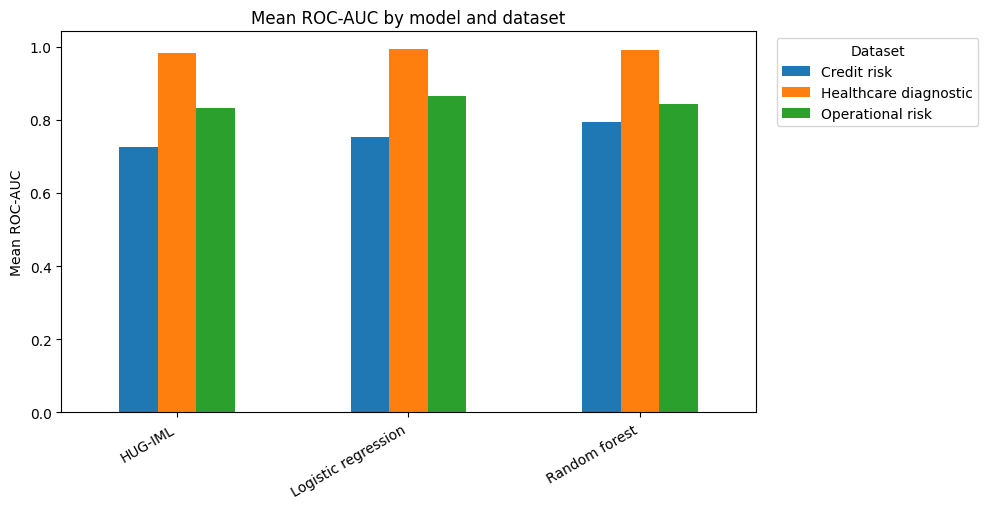

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.2))
plot_df = summary.pivot(index="model", columns="dataset", values="roc_auc_mean")
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Mean ROC-AUC by model and dataset")
ax.set_ylabel("Mean ROC-AUC")
ax.set_xlabel("")
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. HUG-IML interpretability diagnostic

The diagnostic below fits one HUG-IML model on the healthcare dataset and reports its most influential patterns.

In [7]:
X_demo, y_demo = datasets["Healthcare diagnostic"]
X_demo, y_demo = stratified_cap(X_demo, y_demo, max_rows=600)
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.25, stratify=y_demo, random_state=RANDOM_STATE)

hug = hug_for_frame(X_tr)
hug.fit(X_tr, y_tr)
print(hug.model_summary())

pattern_table = hug.get_pattern_info().merge(
    hug.feature_importances()[["pattern", "coefficient", "abs_coefficient"]],
    on="pattern",
    how="left",
).sort_values("abs_coefficient", ascending=False)
pattern_table.head(12)

HUGIMLClassifierNative — Model Summary
Config:       B=7, L=2, G=0.005
Training:     426 samples, 30 features, 2 classes
Patterns:     60 (0 compound)
Matrix:       (426, 60) (density=0.1430)
Fit time:     614 ms

Stage breakdown (ms):
  resolve_meta                  15.2
  prepare_transactions         457.4
  mine_patterns                 57.3
  build_matrix                   1.2
  fit_downstream                 8.6
  compat                         2.9

Top 10 patterns by importance:
  worst concavity=[0.1276,0.1857)          coef= +1.4236  sup=0.143
  worst concave points=[0.06632,0.08477)   coef= +1.3309  sup=0.143
  mean concave points=[0.02835,0.04168)    coef= +1.3236  sup=0.141
  worst texture=[12.02,19.07)              coef= +1.2813  sup=0.143
  worst area=[436.5,533.4)                 coef= +1.2736  sup=0.143
  worst concavity=[0.06626,0.1276)         coef= +1.2545  sup=0.143
  worst perimeter=[92.04,102.2)            coef= +1.2493  sup=0.143
  mean texture=[9.71,14.75)       

,pattern,utility,information_gain,support,coefficient,abs_coefficient
41,"worst concavity=[0.1276,0.1857)",44.988110,0.078616,0.1432,1.423568,1.423568
49,"worst concave points=[0.06632,0.08477)",51.623812,0.090211,0.1432,1.330851,1.330851
4,"mean concave points=[0.02835,0.04168)",21.864840,0.038645,0.1408,1.323575,1.323575
20,"worst texture=[12.02,19.07)",30.259599,0.052878,0.1432,1.281345,1.281345
46,"worst area=[436.5,533.4)",51.623812,0.090211,0.1432,1.273632,1.273632
59,"worst concavity=[0.06626,0.1276)",61.000000,0.106596,0.1432,1.254547,1.254547
22,"worst perimeter=[92.04,102.2)",30.259599,0.052878,0.1432,1.249287,1.249287
25,"mean texture=[9.71,14.75)",34.567602,0.060406,0.1432,1.145782,1.145782
39,"worst perimeter=[85.56,92.04)",44.988110,0.078616,0.1432,1.121678,1.121678
8,"mean symmetry=[0.106,0.1538)",22.918310,0.040049,0.1432,1.104971,1.104971


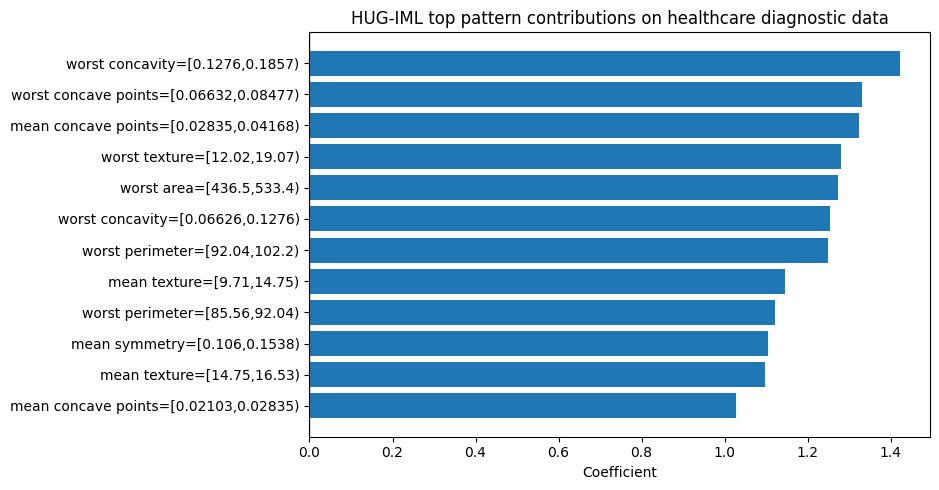

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5))
plot_df = pattern_table.head(12).iloc[::-1]
ax.barh(plot_df["pattern"], plot_df["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("HUG-IML top pattern contributions on healthcare diagnostic data")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

The benchmark separates predictive performance from interpretability review. HUG-IML can be evaluated with the same fold discipline as other classifiers while also exposing compact, auditable pattern tables after fitting.